[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/32%20-%20Demystifying%20Deep%20CNNs%20-%20Implementing%20Max%20Pooling/Demystifying_Deep_CNNs_Implementing_Max_Pooling.ipynb)

# First, a meme

![DeepLearning](https://www.dropbox.com/s/ym7uvbfkxtwj2bw/deep_learning.jpg?raw=1)

Credits: http://www.ryanleeallred.com/

# Overview

Convolutional Neural Networks leverage groupings of different kinds of layers to process image data. Each of these layers performs a specific function that can be understood as a linear algebra transformation of the information that is passed from the previous layer. 

CNNs consist of combinations of four main types of layers:

*   Convolutional Layers
*   Activation Layers (Relu) 
*   Max Pooling Layers
*   Fully Connected Layers


![DeepCNN](https://www.dropbox.com/s/vbxbpp6foai6rsp/CNN-diagram.jpeg?raw=1)


Some previous demystification attempts:

[Image Filtering via Convolution](https://nbviewer.jupyter.org/github/navjotts/ML-experiments/blob/master/27%20-%20Image%20Filtering%20via%20Convolution/Image_Filtering_via_Convolution.ipynb)

[Computer Vision basics](https://nbviewer.jupyter.org/github/navjotts/ML-experiments/blob/master/29%20-%20Computer%20Vision%20basics/Computer_Vision_basics.ipynb)


In [1]:
!pip install imageio

    100% |████████████████████████████████| 3.3MB 8.3MB/s 
  Running setup.py bdist_wheel for imageio ... - \ | / done
  Stored in directory: /root/.cache/pip/wheels/e0/43/31/605de9372ceaf657f152d3d5e82f42cf265d81db8bbe63cde1
Successfully built imageio


Color image dimensions:  (250, 478, 3)
Grayscale image dimensions:  (250, 478)


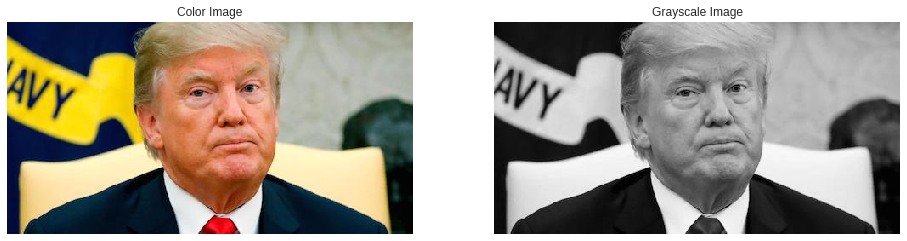

In [12]:
import imageio
import matplotlib.pyplot as plt
import numpy as np
from skimage import color
from skimage.exposure import rescale_intensity

# Read in RGB image 
img = imageio.imread('https://www.dropbox.com/s/rkmgurxc5szovmn/trump3.jpg?raw=1')

# Change image to grayscale
grayscale = rescale_intensity(color.rgb2gray(img))

# Plot both images
plt.figure(figsize=(16, 12))
plt.subplot(121) 
plt.imshow(img, cmap = 'gray')
plt.title('Color Image'),
plt.xticks([]) 
plt.yticks([])

plt.subplot(122)
plt.imshow(grayscale, cmap='gray')
plt.title('Grayscale Image')
plt.xticks([])
plt.yticks([])

print('Color image dimensions: ', img.shape)
print('Grayscale image dimensions: ', grayscale.shape)

# Max Pooling

Let's write a generic `max_pool()` function and try 1st with filter size of 2x2 and a stride of 2

In [0]:
def max_pool(I, filter_size=(2, 2), stride=2):    
  # create a new image with all 0s, but having the shape of the original image divided by stride
  width = int(I.shape[0]/stride)
  height = int(I.shape[1]/stride)
  I_pooled = np.zeros(shape=(width, height))
  
  for i in range(width):
    for j in range(height):
      for x in range(filter_size[0]):
        for y in range(filter_size[1]):
          if (stride*i + x < I.shape[0]) and (stride*j + y < I.shape[1]): # avoid going out of bounds
            I_pooled[i, j] = max(I_pooled[i, j], I[stride*i+x, stride*j+y])
  
  return I_pooled

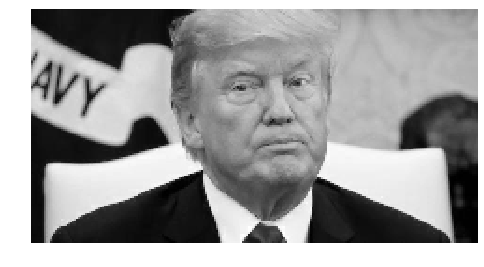

In [14]:
I_pooled = max_pool(grayscale)
plt.axis('off')
plt.imshow(I_pooled, cmap='gray');

Lets do it again - the same operation on the output of the previous state

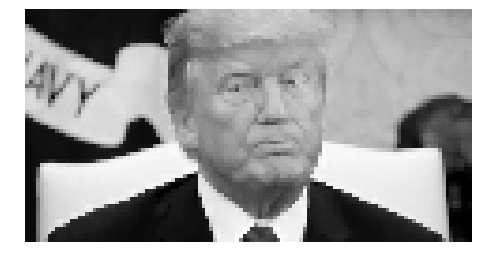

In [15]:
I_pooled = max_pool(I_pooled)
plt.axis('off')
plt.imshow(I_pooled, cmap='gray');

### Try with arbitrary filter sizes and strides

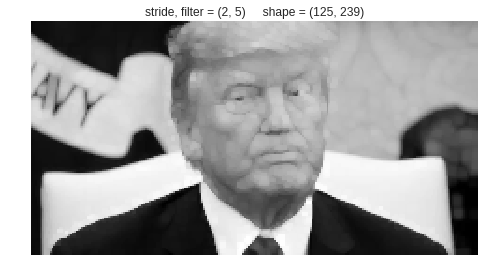

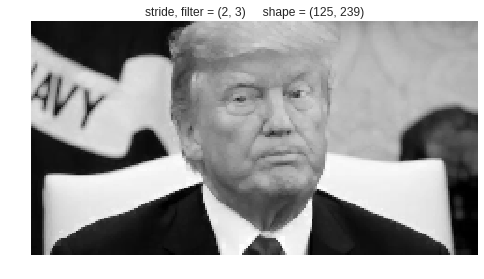

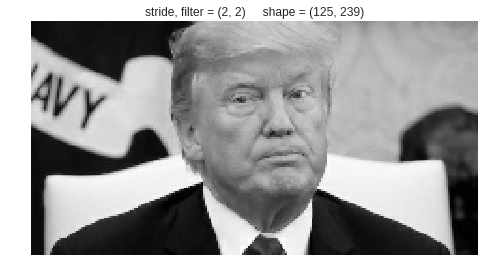

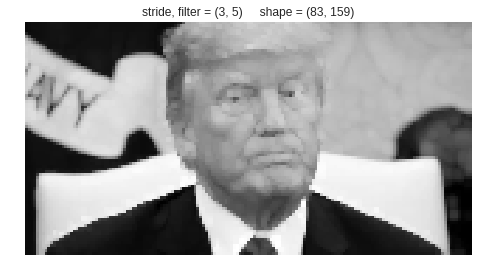

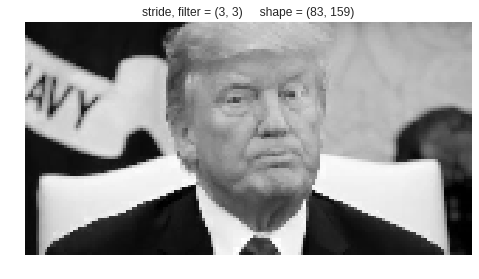

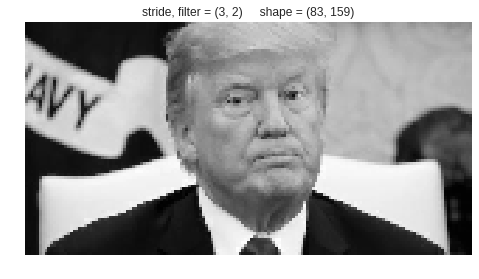

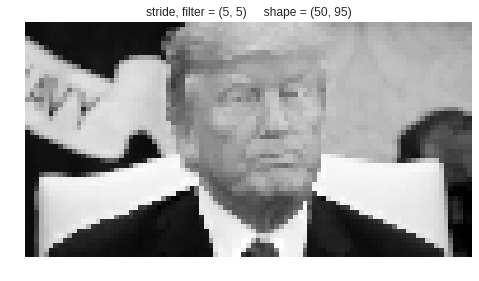

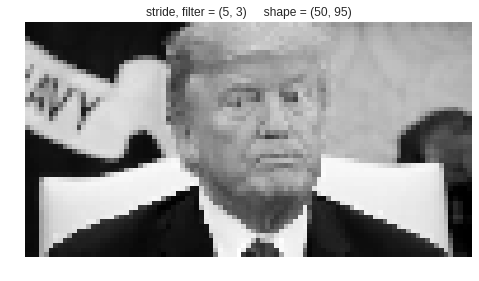

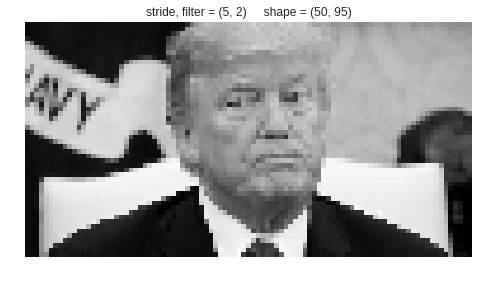

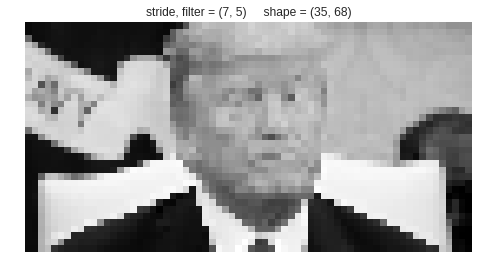

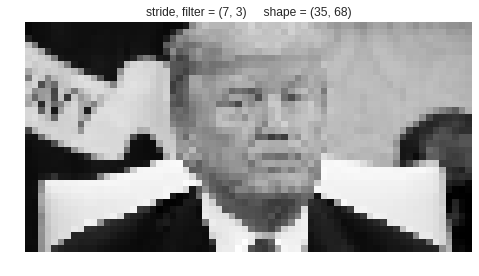

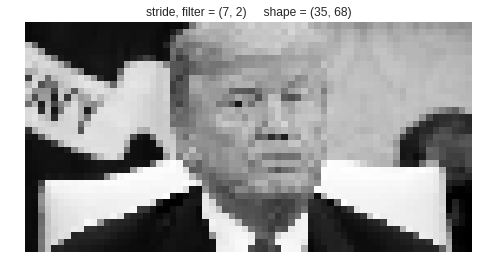

In [16]:
for stride in [2, 3, 5, 7]:
  for filter_size in [5, 3, 2]:
    I_pooled = max_pool(grayscale, (filter_size, filter_size), stride)
    plt.axis('off')
    plt.title("stride, filter = (%d, %d)     shape = %s" % (stride, filter_size, I_pooled.shape))
    plt.imshow(I_pooled, cmap='gray');
    plt.show();